<p style="align: center;"><img src="https://static.tildacdn.com/tild6636-3531-4239-b465-376364646465/Deep_Learning_School.png" width="400"></p>

# Домашнее задание. Обучение языковой модели с помощью LSTM (10 баллов)

Э
В этом задании Вам предстоит обучить языковую модель с помощью рекуррентной нейронной сети. В отличие от семинарского занятия, Вам необходимо будет работать с отдельными словами, а не буквами.


Установим модуль ```datasets```, чтобы нам проще было работать с данными.

In [1]:
!pip install datasets

Импорт необходимых библиотек

In [2]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import numpy as np
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from datasets import load_dataset
from nltk.tokenize import sent_tokenize, word_tokenize
from sklearn.model_selection import train_test_split
import nltk

from collections import Counter
from typing import List

import seaborn
seaborn.set(palette='summer')

In [3]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [4]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

## Подготовка данных

Воспользуемся датасетом imdb. В нем хранятся отзывы о фильмах с сайта imdb. Загрузим данные с помощью функции ```load_dataset```

In [5]:
# Загрузим датасет
dataset = load_dataset('imdb')

README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

### Препроцессинг данных и создание словаря (1 балл)

Далее вам необходмо самостоятельно произвести препроцессинг данных и получить словарь или же просто ```set``` строк. Что необходимо сделать:

1. Разделить отдельные тренировочные примеры на отдельные предложения с помощью функции ```sent_tokenize``` из бибилиотеки ```nltk```. Каждое отдельное предложение будет одним тренировочным примером.
2. Оставить только те предложения, в которых меньше ```word_threshold``` слов.
3. Посчитать частоту вхождения каждого слова в оставшихся предложениях. Для деления предлоения на отдельные слова удобно использовать функцию ```word_tokenize```.
4. Создать объект ```vocab``` класса ```set```, положить в него служебные токены '\<unk\>', '\<bos\>', '\<eos\>', '\<pad\>' и vocab_size самых частовстречающихся слов.   

In [6]:
sentences = []
word_threshold = 32

for text in tqdm(dataset["train"]["text"]):
    for sent in sent_tokenize(text):
        sent = sent.lower()
        if len(word_tokenize(sent)) < word_threshold:
            sentences.append(sent)

  0%|          | 0/25000 [00:00<?, ?it/s]

In [7]:
print("Всего предложений:", len(sentences))

Всего предложений: 198801


Посчитаем для каждого слова его встречаемость.

In [8]:
words = Counter()
for sentence in tqdm(sentences):
    for word in word_tokenize(sentence):
        words[word] += 1

# Расчет встречаемости слов

  0%|          | 0/198801 [00:00<?, ?it/s]

Добавим в словарь ```vocab_size``` самых встречающихся слов.

In [9]:
print(len(words))

68415


In [10]:
vocab = set(['<unk>', '<bos>', '<eos>', '<pad>'])
vocab_size = 40000

# Наполнение словаря
most_common_words = [word for word, _ in words.most_common(vocab_size)]
vocab.update(most_common_words)

In [11]:
assert '<unk>' in vocab
assert '<bos>' in vocab
assert '<eos>' in vocab
assert '<pad>' in vocab
assert len(vocab) == vocab_size + 4

In [12]:
print("Всего слов в словаре:", len(vocab))

Всего слов в словаре: 40004


### Подготовка датасета (1 балл)

Далее, как и в семинарском занятии, подготовим датасеты и даталоадеры.

В классе ```WordDataset``` вам необходимо реализовать метод ```__getitem__```, который будет возвращать сэмпл данных по входному idx, то есть список целых чисел (индексов слов).

Внутри этого метода необходимо добавить служебные токены начала и конца последовательности, а также токенизировать соответствующее предложение с помощью ```word_tokenize``` и сопоставить ему индексы из ```word2ind```.

In [13]:
word2ind = {word: i for i, word in enumerate(vocab)}
ind2word = {i: word for word, i in word2ind.items()}

In [14]:
class WordDataset:
    def __init__(self, sentences):
        self.data = sentences
        self.unk_id = word2ind['<unk>']
        self.bos_id = word2ind['<bos>']
        self.eos_id = word2ind['<eos>']
        self.pad_id = word2ind['<pad>']

    def __getitem__(self, idx: int) -> List[int]:
        tokenized_sentence = ([self.bos_id] +
        [word2ind.get(word, self.unk_id) for word in word_tokenize(self.data[idx])] +
        [self.eos_id])
        
        return tokenized_sentence

    def __len__(self) -> int:
        return len(self.data)

In [15]:
def collate_fn_with_padding(
    input_batch: List[List[int]], pad_id=word2ind['<pad>']) -> torch.Tensor:
    seq_lens = [len(x) for x in input_batch]
    max_seq_len = max(seq_lens)

    new_batch = []
    for sequence in input_batch:
        for _ in range(max_seq_len - len(sequence)):
            sequence.append(pad_id)
        new_batch.append(sequence)

    sequences = torch.LongTensor(new_batch).to(device)

    new_batch = {
        'input_ids': sequences[:,:-1],
        'target_ids': sequences[:,1:]
    }

    return new_batch

In [16]:
train_sentences, eval_sentences = train_test_split(sentences, test_size=0.2)
eval_sentences, test_sentences = train_test_split(eval_sentences, test_size=0.5)

train_dataset = WordDataset(train_sentences)
eval_dataset = WordDataset(eval_sentences)
test_dataset = WordDataset(test_sentences)

batch_size = 128

train_dataloader = DataLoader(
    train_dataset, collate_fn=collate_fn_with_padding, batch_size=batch_size)

eval_dataloader = DataLoader(
    eval_dataset, collate_fn=collate_fn_with_padding, batch_size=batch_size)

test_dataloader = DataLoader(
    test_dataset, collate_fn=collate_fn_with_padding, batch_size=batch_size)

## Обучение и архитектура модели

Вам необходимо на практике проверить, что влияет на качество языковых моделей. В этом задании нужно провести серию экспериментов с различными вариантами языковых моделей и сравнить различия в конечной перплексии на тестовом множестве.

Возмоэные идеи для экспериментов:

* Различные RNN-блоки, например, LSTM или GRU. Также можно добавить сразу несколько RNN блоков друг над другом с помощью аргумента num_layers. Вам поможет официальная документация [здесь](https://pytorch.org/docs/stable/generated/torch.nn.LSTM.html)
* Различные размеры скрытого состояния. Различное количество линейных слоев после RNN-блока. Различные функции активации.
* Добавление нормализаций в виде Dropout, BatchNorm или LayerNorm
* Различные аргументы для оптимизации, например, подбор оптимального learning rate или тип алгоритма оптимизации SGD, Adam, RMSProp и другие
* Любые другие идеи и подходы

После проведения экспериментов необходимо составить таблицу результатов, в которой описан каждый эксперимент и посчитана перплексия на тестовом множестве.

Учтите, что эксперименты, которые различаются, например, только размером скрытого состояния или количеством линейных слоев считаются, как один эксперимент.

Успехов!

### Функция evaluate (1 балл)

Заполните функцию ```evaluate```

In [17]:
def evaluate(model, criterion, dataloader, device) -> float:
    model.eval()
    total_loss = 0.0
    total_tokens = 0

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            target_ids = batch["target_ids"].to(device)

            logits = model(input_ids)
            logits = logits.reshape(-1, logits.shape[-1])
            target_ids = target_ids.reshape(-1)

            valid_tokens = (target_ids != word2ind["<pad>"]).sum().item()
            loss = criterion(logits, target_ids)

            total_loss += loss.item() * valid_tokens
            total_tokens += valid_tokens

    mean_loss = total_loss / total_tokens
    perplexity = np.exp(mean_loss)
    return perplexity

### Train loop (1 балл)

Напишите функцию для обучения модели.

In [18]:
def train_model(epochs, model, loss_func, optimizer, train_dataloader, eval_dataloader, device, disable_tqdm=False):
    model.to(device)
    loss_epochs = []
    perplexities = []

    for epoch in range(epochs):
        if not disable_tqdm:
            print(f"Epoch {epoch + 1}:")
        model.train()
        loss_cur = []

        for batch in tqdm(train_dataloader,  disable =disable_tqdm):
            input_ids = batch["input_ids"].to(device)
            target_ids = batch["target_ids"].to(device)

            optimizer.zero_grad()

            logits = model(input_ids)
            logits = logits.reshape(-1, logits.shape[-1])
            target_ids = target_ids.reshape(-1)

            loss = loss_func(logits, target_ids)
            loss.backward()
            optimizer.step()

            loss_cur.append(loss.item())

        epoch_loss = sum(loss_cur) / len(loss_cur)
        epoch_perplexity = evaluate(model, loss_func, eval_dataloader, device)

        loss_epochs.append(epoch_loss)
        perplexities.append(epoch_perplexity)

        if not disable_tqdm:
            print(f"Loss: {epoch_loss:.4f}      Perplexity: {epoch_perplexity:.4f}")

    return loss_epochs, perplexities

### Первый эксперимент (2 балла)

Определите архитектуру модели и обучите её.

In [19]:
class LanguageModel(nn.Module):
    def __init__(self, vocab_size, hidden_size, num_layers=1, model_name = "Vanila"):
        super().__init__()
        self.embeddings = nn.Embedding(vocab_size, hidden_size, padding_idx=word2ind['<pad>'])
        
        if model_name == "Vanila":
            self.rnn = nn.RNN(hidden_size,
            hidden_size,
            num_layers=num_layers,
            batch_first=True)
            
        elif model_name == "GRU":
            self.rnn = nn.GRU(
                hidden_size,
                hidden_size,
                num_layers=num_layers,
                batch_first=True
            )
            
        elif model_name == "LSTM":
            self.rnn = nn.LSTM(
                hidden_size,
                hidden_size,
                num_layers=num_layers,
                batch_first=True
            )
        
        
        self.linear_1 = nn.Linear(hidden_size, hidden_size)
        self.non_lin = nn.Tanh()
        self.linear_2 = nn.Linear(hidden_size, vocab_size)
        self.dropout = nn.Dropout(p=0.1)

    def forward(self, input_batch: torch.Tensor) -> torch.Tensor:
        emb = self.embeddings(input_batch)
        out_rnn, _ = self.rnn(emb)
        out = self.linear_1(self.non_lin(out_rnn))
        out = self.non_lin(out)
        out = self.dropout(out)
        out = self.linear_2(out)
        return out


In [20]:
# Обучите модель здесь
model = LanguageModel(len(vocab), hidden_size = 64, num_layers = 2, model_name = "Vanila")
criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer = torch.optim.AdamW(model.parameters())
device = 'cuda' if torch.cuda.is_available() else 'cpu'
epochs = 10
loss, perplexities = train_model(epochs, model, criterion, optimizer, train_dataloader, eval_dataloader, device)

Epoch 1:


  0%|          | 0/1243 [00:00<?, ?it/s]

Loss: 6.0507      Perplexity: 231.7053
Epoch 2:


  0%|          | 0/1243 [00:00<?, ?it/s]

Loss: 5.3165      Perplexity: 183.7318
Epoch 3:


...

Loss: 4.8150      Perplexity: 134.5377
Epoch 9:


  0%|          | 0/1243 [00:00<?, ?it/s]

Loss: 4.7953      Perplexity: 140.5772
Epoch 10:


  0%|          | 0/1243 [00:00<?, ?it/s]

Loss: 4.7737      Perplexity: 132.2350


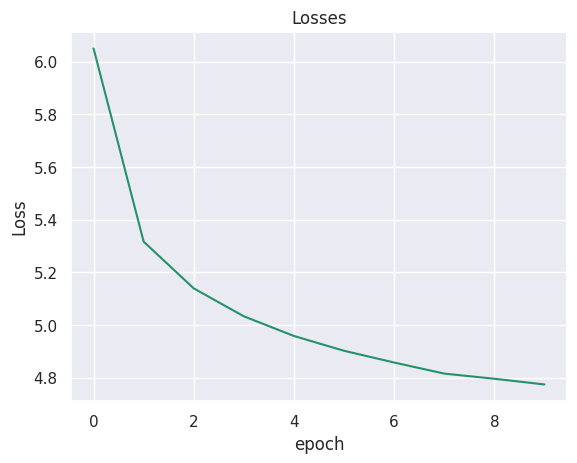

In [21]:
plt.plot(np.arange(len(loss)), loss)
plt.title("Losses")
plt.xlabel("epoch")
plt.ylabel("Loss")
plt.show()

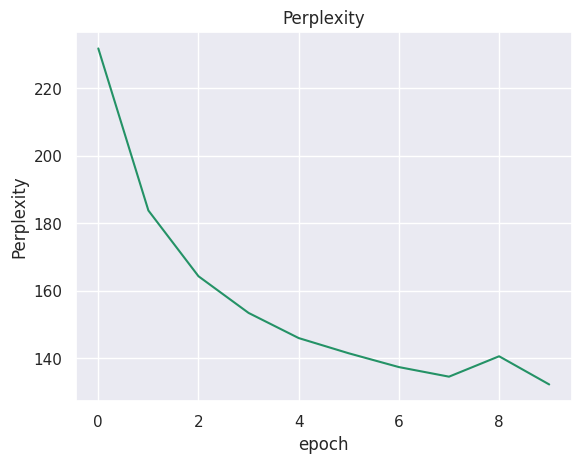

In [22]:
plt.plot(np.arange(len(perplexities)), perplexities)
plt.title("Perplexity")
plt.xlabel("epoch")
plt.ylabel("Perplexity")
plt.show()

In [23]:
test_perplexity = evaluate(model, criterion, test_dataloader, device)
print(f"Test perplexity: {test_perplexity:.4f}")

Test perplexity: 131.6233


### Второй эксперимент (2 балла)

Попробуйте что-то поменять в модели или в пайплайне обучения, идеи для экспериментов можно подсмотреть выше.

In [24]:
# Обучите модель здесь
model = LanguageModel(len(vocab), hidden_size = 64, num_layers = 2, model_name = "GRU")
criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer = torch.optim.AdamW(model.parameters())
device = 'cuda' if torch.cuda.is_available() else 'cpu'
epochs = 10
loss, perplexities = train_model(epochs, model, criterion, optimizer, train_dataloader, eval_dataloader, device)

Epoch 1:


  0%|          | 0/1243 [00:00<?, ?it/s]

Loss: 6.3559      Perplexity: 313.3370
Epoch 2:


  0%|          | 0/1243 [00:00<?, ?it/s]

Loss: 5.4586      Perplexity: 197.1924
Epoch 3:


...

Loss: 4.7957      Perplexity: 131.7779
Epoch 9:


  0%|          | 0/1243 [00:00<?, ?it/s]

Loss: 4.7563      Perplexity: 129.3208
Epoch 10:


  0%|          | 0/1243 [00:00<?, ?it/s]

Loss: 4.7217      Perplexity: 127.3485


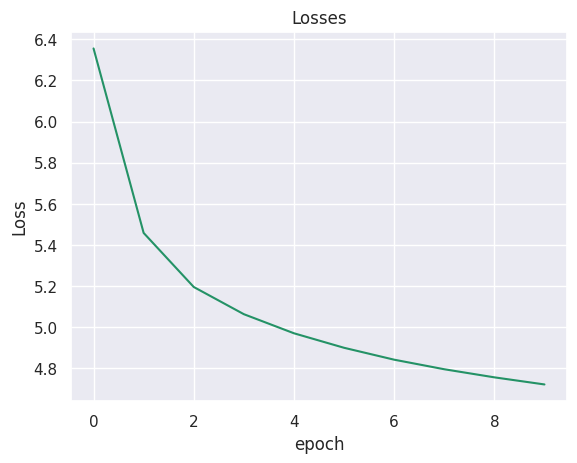

In [25]:
plt.plot(np.arange(len(loss)), loss)
plt.title("Losses")
plt.xlabel("epoch")
plt.ylabel("Loss")
plt.show()

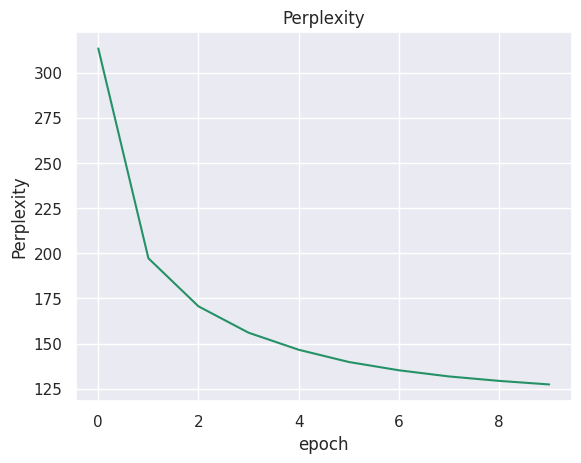

In [26]:
plt.plot(np.arange(len(perplexities)), perplexities)
plt.title("Perplexity")
plt.xlabel("epoch")
plt.ylabel("Perplexity")
plt.show()

In [27]:
test_perplexity = evaluate(model, criterion, test_dataloader, device)
print(f"Test perplexity: {test_perplexity:.4f}")

Test perplexity: 126.6950


### Третий эксперимент 


In [28]:
# Обучите модель здесь
for layers in [1, 2, 3, 4, 5]:
    model = LanguageModel(len(vocab), hidden_size = 64, num_layers = layers, model_name = "GRU")
    criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
    optimizer = torch.optim.AdamW(model.parameters())
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    epochs = 10
    loss, perplexities = train_model(epochs, model, criterion,optimizer,
        train_dataloader,eval_dataloader, device, disable_tqdm = True)

    print(f"Num_layers = {layers}: Loss: {loss[-1]}     Perplexity: {perplexities[-1]}")
    test_perplexity = evaluate(model, criterion, test_dataloader, device)
    print(f"Test perplexity: {test_perplexity:.4f}")

Num_layers = 1: Loss: 4.688969401131689     Perplexity: 126.4481383420236
Test perplexity: 126.0495
Num_layers = 2: Loss: 4.710810591113827     Perplexity: 126.03293521795392
Test perplexity: 125.7536
Num_layers = 3: Loss: 4.698144722445205     Perplexity: 124.78093731952684
Test perplexity: 124.1528
Num_layers = 4: Loss: 4.722339778587115     Perplexity: 127.20567757710761
Test perplexity: 126.7367
Num_layers = 5: Loss: 4.803261091319765     Perplexity: 134.29708739977318
Test perplexity: 134.0426


### Отчет (2 балла)

Опишите проведенные эксперименты. Сравните перплексии полученных моделей. Предложите идеи по улучшению качества моделей.

В данной работе была обучена языковая модель на предложениях из датасета **IMDB**. На этапе подготовки данных все отзывы были разбиты на отдельные предложения, переведены в нижний регистр, а в выборку были оставлены только предложения короче `32` слов. В результате было получено `198801` предложений. После подсчета частот слов был построен словарь размером `40004` токена, включая специальные токены `<unk>`, `<bos>`, `<eos>` и `<pad>`.

Обучение проводится на `train_dataloader`, качество по эпохам отслеживается на `eval_dataloader`, а итоговая оценка считается отдельно на `test_dataloader`. Для оценки качества используется метрика **perplexity**: чем она ниже, тем лучше модель предсказывает следующее слово.

### Эксперимент 1: Vanilla RNN, `hidden_size = 64`, `num_layers = 2`

В первом эксперименте была обучена базовая модель на основе обычной `RNN`. По мере обучения качество стабильно улучшалось: валидационная perplexity уменьшилась с `231.7053` на первой эпохе до `132.2350` на десятой. Итоговая perplexity на тестовой выборке составила:

- `Test Perplexity = 131.6233`

Эту модель можно рассматривать как baseline для дальнейшего сравнения.

### Эксперимент 2: GRU, `hidden_size = 64`, `num_layers = 2`

Во втором эксперименте вместо обычной `RNN` была использована `GRU`. На первых эпохах `GRU` стартовала немного хуже baseline, но затем постепенно улучшила результат и к концу обучения показала более низкую perplexity. Валидационная perplexity снизилась с `313.3370` до `127.3485`, а итоговая тестовая perplexity составила:

- `Test Perplexity = 126.6950`

Таким образом, `GRU` с двумя слоями оказалась лучше базовой `RNN` и дала более качественную языковую модель.

### Эксперимент 3: влияние числа слоев `num_layers` для GRU

В третьем эксперименте исследовалось влияние количества рекуррентных слоев в `GRU`. Были проверены значения `num_layers` от `1` до `5`. Полученные результаты:

- `num_layers = 1`  
  `Eval Perplexity = 126.4481`  
  `Test Perplexity = 126.0495`

- `num_layers = 2`  
  `Eval Perplexity = 126.0329`  
  `Test Perplexity = 125.7536`

- `num_layers = 3`  
  `Eval Perplexity = 124.7809`  
  `Test Perplexity = 124.1528`

- `num_layers = 4`  
  `Eval Perplexity = 127.2057`  
  `Test Perplexity = 126.7367`

- `num_layers = 5`  
  `Eval Perplexity = 134.2971`  
  `Test Perplexity = 134.0426`

Лучший результат показала модель с **тремя слоями**. При увеличении числа слоев до `4` качество снова ухудшилось, а при `5` слоях стало заметно хуже. Это означает, что слишком глубокая рекуррентная сеть для данной задачи уже труднее оптимизируется и не дает прироста качества.

### Сравнение результатов

Итоговое сравнение моделей по **test perplexity**:

1. **GRU, 3 слоя** - `124.1528`
2. **GRU, 2 слоя (подбор по слоям)** - `125.7536`
3. **GRU, 1 слой** - `126.0495`
4. **GRU, 2 слоя** - `126.6950`
5. **GRU, 4 слоя** - `126.7367`
6. **Vanilla RNN, 2 слоя** - `131.6233`
7. **GRU, 5 слоев** - `134.0426`

Из экспериментов видно следующее:
- замена `Vanilla RNN` на `GRU` действительно улучшает качество модели;
- среди проверенных конфигураций наилучший результат дала **GRU с тремя слоями**;
- слишком глубокая модель (`5` слоев) работает заметно хуже, что может быть связано с более сложной оптимизацией и ухудшением устойчивости обучения.

### Вывод по экспериментам

Проведенные эксперименты показали, что для данной задачи языкового моделирования архитектура `GRU` подходит лучше, чем обычная `RNN`. При этом оптимальное число слоев оказалось не минимальным и не слишком большим: наилучший результат был получен при `num_layers = 3`. Это означает, что небольшое увеличение глубины помогает модели лучше учитывать контекст, но чрезмерное усложнение архитектуры уже начинает мешать.

Таким образом, лучшей моделью среди протестированных конфигураций стала:

- **GRU**
- `hidden_size = 64`
- `num_layers = 3`
- `Test Perplexity = 124.1528`

## Что можно улучшить дальше

Для дальнейшего улучшения качества модели можно попробовать следующие направления:

### 1. Подобрать количество эпох

Сейчас все модели обучались `10` эпох. Имеет смысл дополнительно проверить:
- `15`, `20`, `25` эпох;
- **early stopping** по валидационной perplexity;
- сохранение лучшей модели по минимальной `eval perplexity`.

### 2. Подобрать `hidden_size`

Во всех экспериментах использовалось `hidden_size = 64`. Можно попробовать:
- `hidden_size = 128`
- `hidden_size = 256`

Более крупное скрытое состояние может позволить модели лучше хранить контекст.

### 3. Попробовать другую функцию активации

Сейчас используется `Tanh`. Можно проверить:
- `ReLU`
- `LeakyReLU`
- `GELU`

Это может повлиять на устойчивость обучения и качество итоговой модели.

### 4. Улучшить процесс обучения

Дополнительно можно попробовать:
- добавить **gradient clipping**;
- подобрать `learning rate`;
- использовать scheduler, например `ReduceLROnPlateau`;
- увеличить `dropout`, если начнет появляться переобучение.

## Итоговый вывод

В работе были проведены эксперименты с базовой `Vanilla RNN`, `GRU`, а также с разным числом слоев для `GRU`. Лучшие результаты показала именно `GRU`, причем оптимальной среди протестированных конфигураций оказалась модель с **тремя слоями**. Это позволяет сделать вывод, что для word-level language modeling на предложениях из IMDB рекуррентная архитектура `GRU` является более эффективной, чем обычная `RNN`, а умеренное увеличение глубины действительно может улучшать качество модели.
